# Fraud Detection System — IEEE-CIS Dataset

----
## Task 1 — Data Loading, Merging & Exploratory Analysis

### 1.1 — Importing Libraries
Importing all the libraries I'll need for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries imported successfully")

Libraries imported successfully


### 1.2 — Loading & Merging Data
Loading both CSV files and merging them on TransactionID. Using left join so we keep all transactions even if they don't have identity info.

In [2]:
# loading both csv files 
transaction = pd.read_csv('data/train_transaction.csv')
identity = pd.read_csv('data/train_identity.csv')

print("transaction shape:", transaction.shape)
print("identity shape:", identity.shape)

# merging both on TransactionID
df = pd.merge(transaction, identity, on='TransactionID', how='left')

print("merged shape:", df.shape)

transaction shape: (590540, 394)
identity shape: (144233, 41)
merged shape: (590540, 434)


### 1.3 — First Look at the Data
Checking the shape, column types and first few rows to understand what we're working with.

In [3]:
# just checking what the data looks like
print("first 5 rows:")
display(df.head())

print("\ncolumn types:")
print(df.dtypes.value_counts())

first 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,...,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



column types:
float64    399
object      31
int64        4
Name: count, dtype: int64


### 1.4 — Checking Class Imbalance
Checking how many fraud vs legitimate transactions we have. This is important because if fraud is very rare the model might just ignore it.

In [4]:
# how many frauds vs normal transactions?
print("fraud counts:")
print(df['isFraud'].value_counts())

print("\nin percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

fraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

in percentage:
isFraud
0   96.5010
1    3.4990
Name: proportion, dtype: float64


### 1.5 — Visualizing Class Imbalance

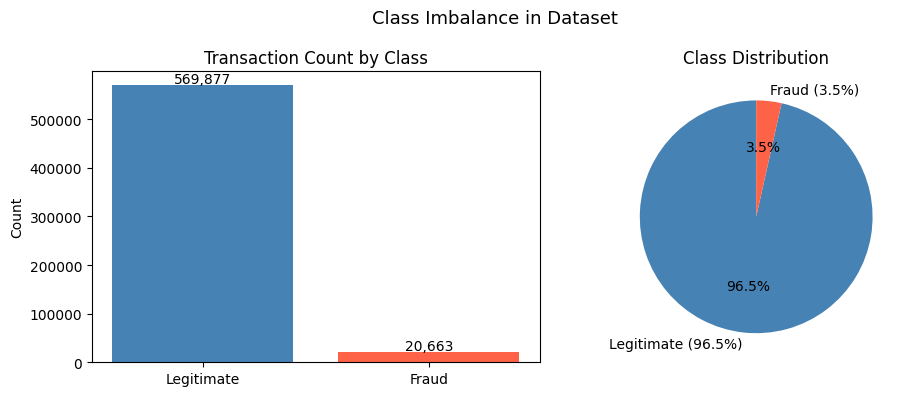

In [5]:
# plotting the class imbalance so we can see it visually
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar chart
axes[0].bar(['Legitimate', 'Fraud'], [569877, 20663], color=['steelblue', 'tomato'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
axes[0].text(0, 569877 + 5000, '569,877', ha='center')
axes[0].text(1, 20663 + 5000, '20,663', ha='center')

# pie chart
axes[1].pie([569877, 20663], labels=['Legitimate (96.5%)', 'Fraud (3.5%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Class Imbalance in Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('charts/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.6 — Missing Value Analysis

In [6]:
# checking how many values are missing in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# putting it in a nice table
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f"total columns with missing values: {len(missing_df)}")
print(f"columns with more than 50% missing (will drop these): {(missing_df['missing_pct'] > 50).sum()}")
print(f"columns with less than 50% missing (will impute these): {(missing_df['missing_pct'] <= 50).sum()}")

print("\ntop 20 most missing columns:")
print(missing_df.head(20))

total columns with missing values: 414
columns with more than 50% missing (will drop these): 214
columns with less than 50% missing (will impute these): 200

top 20 most missing columns:
       missing_count  missing_pct
id_24         585793      99.1962
id_25         585408      99.1310
id_07         585385      99.1271
id_08         585385      99.1271
id_21         585381      99.1264
id_26         585377      99.1257
id_22         585371      99.1247
id_27         585371      99.1247
id_23         585371      99.1247
dist2         552913      93.6284
D7            551623      93.4099
id_18         545427      92.3607
D13           528588      89.5093
D14           528353      89.4695
D12           525823      89.0410
id_04         524216      88.7689
id_03         524216      88.7689
D6            517353      87.6068
id_33         517251      87.5895
D8            515614      87.3123


### 1.7 — Visualizing Missing Values

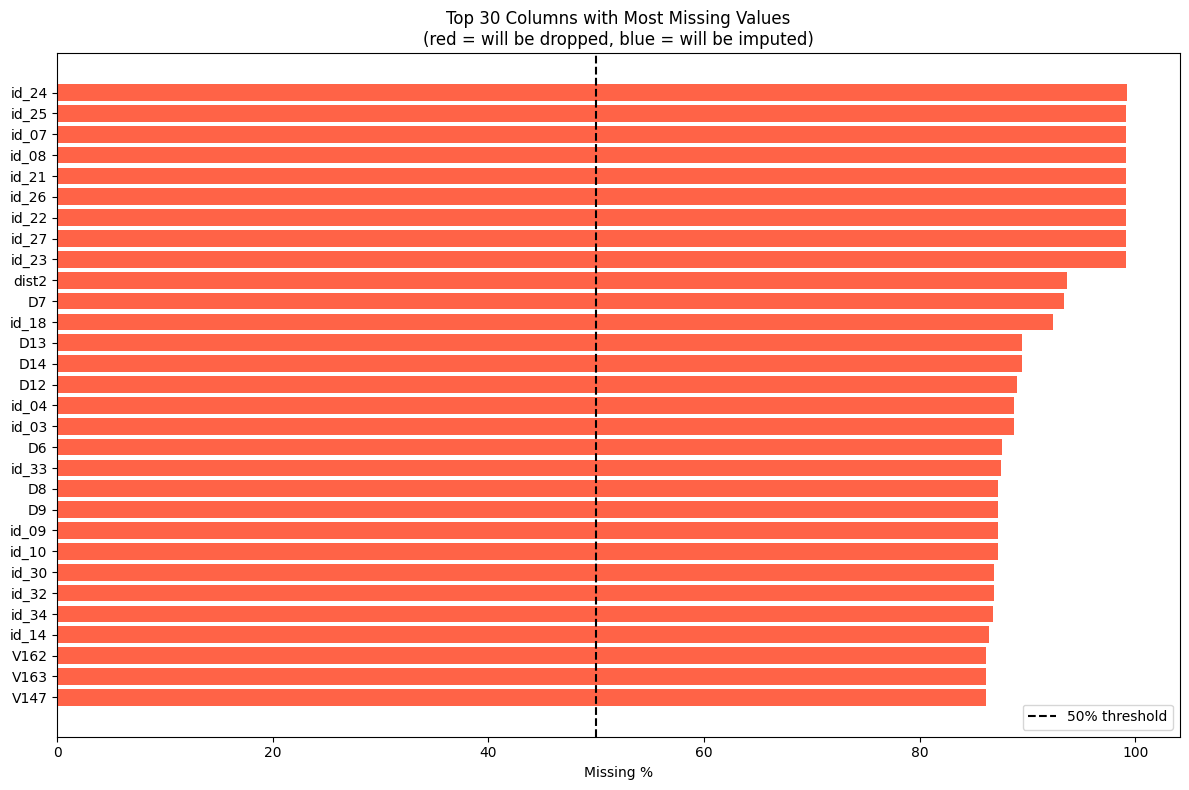

In [7]:
# visualizing top 30 most missing columns
top30 = missing_df.head(30)

plt.figure(figsize=(12, 8))
colors = ['tomato' if x > 50 else 'steelblue' for x in top30['missing_pct']]
plt.barh(top30.index, top30['missing_pct'], color=colors)
plt.axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50% threshold')
plt.xlabel('Missing %')
plt.title('Top 30 Columns with Most Missing Values\n(red = will be dropped, blue = will be imputed)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('charts/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 — Transaction Amount Distribution

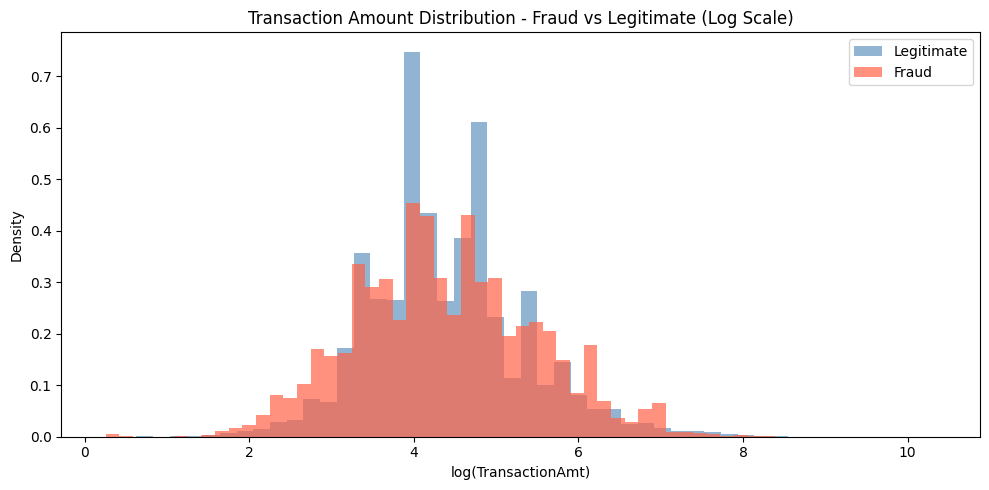

Fraud transactions - avg amount: 149.24
Legit transactions - avg amount: 134.51


In [8]:
# comparing transaction amounts for fraud vs normal
fraud = df[df['isFraud'] == 1]['TransactionAmt']
legit = df[df['isFraud'] == 0]['TransactionAmt']

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(legit), bins=50, alpha=0.6, color='steelblue', label='Legitimate', density=True)
plt.hist(np.log1p(fraud), bins=50, alpha=0.7, color='tomato', label='Fraud', density=True)
plt.xlabel('log(TransactionAmt)')
plt.ylabel('Density')
plt.title('Transaction Amount Distribution - Fraud vs Legitimate (Log Scale)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/transaction_amt.png', dpi=150, bbox_inches='tight')
plt.show()

# also print some basic stats
print("Fraud transactions - avg amount:", round(fraud.mean(), 2))
print("Legit transactions - avg amount:", round(legit.mean(), 2))

### 1.9 — Correlation Heatmap

Task was destroyed but it is pending!
task: <Task pending name='Task-172' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Devendra\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-173' coro=<Kernel.shell_main() running at C:\Users\Devendra\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Devendra\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-173' coro=<Kernel.shell_main() running at C:\Users\Devendra\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


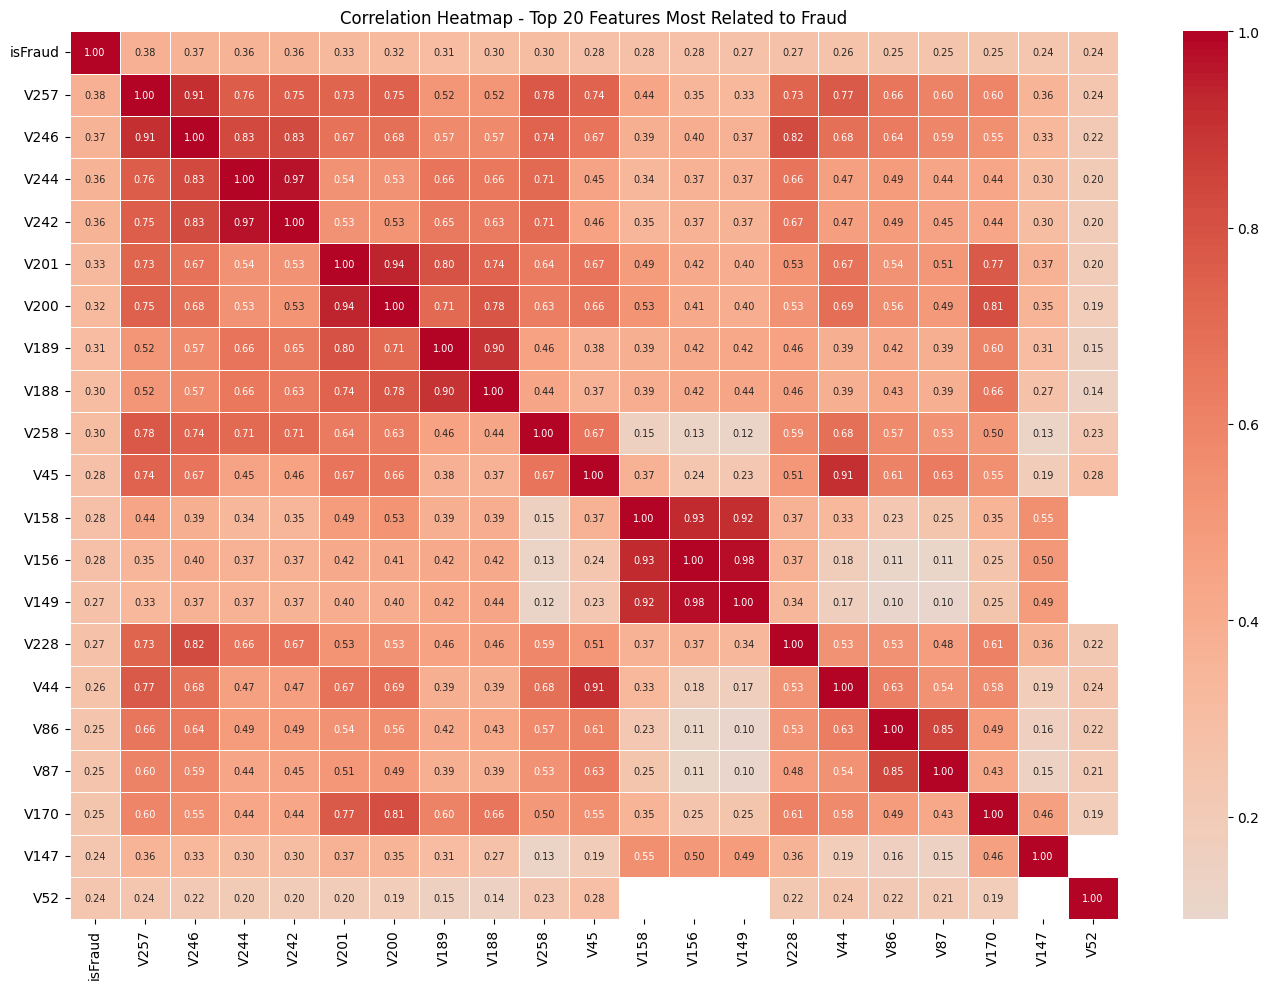

In [10]:
# finding which numerical features are most correlated with fraud
# picking top 20 features most related to isFraud

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['TransactionID']]

# get top 20 columns most correlated with isFraud
top_corr = df[num_cols].corr()['isFraud'].abs().nlargest(21).index.tolist()

corr_matrix = df[top_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 7})
plt.title('Correlation Heatmap - Top 20 Features Most Related to Fraud')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Heatmap Observations:

- V257, V246, V244, V242 are the most correlated features with isFraud (0.36-0.38)
- Many V features are highly correlated with each other (0.90+) — this means some are redundant
- No single feature has very high correlation with fraud alone — so we need ML to combine them
- This confirms why a simple rule-based system won't work well here

----
## Task 2 — Preprocessing, Imbalance Handling & Feature Engineering

### 2.1 — Drop High Missing Columns
Dropping all columns with more than 50% missing values. Imputing more than half the column would just be making up data which can mislead the model.

In [11]:
# dropping all columns with more than 50% missing values
cols_to_drop = missing_df[missing_df['missing_pct'] > 50].index.tolist()

print(f"dropping {len(cols_to_drop)} columns...")
df_clean = df.drop(columns=cols_to_drop)

print(f"shape before: {df.shape}")
print(f"shape after:  {df_clean.shape}")

dropping 214 columns...
shape before: (590540, 434)
shape after:  (590540, 220)


### 2.2 — Fill Remaining Missing Values
For columns under 50% missing I'll fill them using median for numbers and mode for text.

In [12]:
# separating numerical and categorical columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"numerical columns: {len(num_cols)}")
print(f"categorical columns: {len(cat_cols)}")

# fill numerical with median (better than mean because of outliers)
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# fill categorical with mode (most frequent value)
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# check if any missing values left
print(f"\nmissing values remaining: {df_clean.isnull().sum().sum()}")

numerical columns: 211
categorical columns: 9

missing values remaining: 0


### Why these imputation strategies?

- Used median for numerical columns because median is not affected by outliers unlike mean
- Used mode for categorical columns because it fills with the most common category which makes sense for things like card type or email domain
- After imputation, 0 missing values remain — data is clean now

### 2.3 — Label Encoding
Converting text columns to numbers so the model can understand them.

In [13]:
# converting text columns to numbers so the model can understand them
# using label encoding for high cardinality columns (too many unique values for one-hot)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    print(f"{col} — unique values: {df_clean[col].nunique()}")
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("\ndone encoding!")

ProductCD — unique values: 5
card4 — unique values: 4
card6 — unique values: 4
P_emaildomain — unique values: 59
M1 — unique values: 2
M2 — unique values: 2
M3 — unique values: 2
M4 — unique values: 3
M6 — unique values: 2

done encoding!


### 2.4 — Feature Engineering
Creating 3 new features that I think will help the model detect fraud patterns better.

In [14]:
# creating 3 new features that might help detect fraud better

# 1. how does this transaction compare to the average amount?
df_clean['AmtToMeanRatio'] = df_clean['TransactionAmt'] / df_clean['TransactionAmt'].mean()

# 2. what hour of day did the transaction happen?
# TransactionDT is seconds from a reference point, so dividing by 3600 gives hours
df_clean['HourOfDay'] = (df_clean['TransactionDT'] / 3600) % 24
df_clean['HourOfDay'] = df_clean['HourOfDay'].astype(int)

# 3. log of transaction amount - helps reduce skewness
df_clean['LogAmt'] = np.log1p(df_clean['TransactionAmt'])

print("new features created!")
print(df_clean[['TransactionAmt', 'AmtToMeanRatio', 'HourOfDay', 'LogAmt']].head())

new features created!
   TransactionAmt  AmtToMeanRatio  HourOfDay  LogAmt
0         68.5000          0.5073          0  4.2413
1         29.0000          0.2148          0  3.4012
2         59.0000          0.4369          0  4.0943
3         50.0000          0.3703          0  3.9318
4         50.0000          0.3703          0  3.9318


### 2.5 — Train Test Split
80% training, 20% testing. Using stratify so both sets have same fraud ratio.

In [15]:
from sklearn.model_selection import train_test_split

# separating features and target
X = df_clean.drop(columns=['isFraud', 'TransactionID'])
y = df_clean['isFraud']

print(f"features shape: {X.shape}")
print(f"target shape: {y.shape}")

# stratified split so both train and test have same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"\ntrain size: {X_train.shape}")
print(f"test size:  {X_test.shape}")
print(f"\nfraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"fraud in test:  {y_test.sum()} ({y_test.mean()*100:.2f}%)")

features shape: (590540, 221)
target shape: (590540,)

train size: (472432, 221)
test size:  (118108, 221)

fraud in train: 16530 (3.50%)
fraud in test:  4133 (3.50%)


### 2.6 — SMOTE
Balancing the training data so the model actually learns fraud patterns and doesn't just predict "not fraud" every time.

In [16]:
from imblearn.over_sampling import SMOTE

print(f"before SMOTE — fraud: {y_train.sum()}, legit: {(y_train==0).sum()}")

# applying SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"after SMOTE  — fraud: {y_train_sm.sum()}, legit: {(y_train_sm==0).sum()}")
print(f"\nnew training size: {X_train_sm.shape}")

before SMOTE — fraud: 16530, legit: 455902
after SMOTE  — fraud: 455902, legit: 455902

new training size: (911804, 221)


### 2.6 Results
- Before SMOTE: 16,530 fraud vs 455,902 legitimate
- After SMOTE: 455,902 vs 455,902 — perfectly balanced
- Only applied on training data, test data kept original

In [17]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("scaling done!")
print(f"train shape: {X_train_scaled.shape}")
print(f"test shape:  {X_test_scaled.shape}")

scaling done!
train shape: (911804, 221)
test shape:  (118108, 221)


### 2.7 — Scaling Results

Used RobustScaler instead of StandardScaler because RobustScaler uses median and IQR instead of mean — so it handles outliers better. Transaction data has a lot of outliers so this makes more sense here.

- Train shape: (911804, 221)
- Test shape: (118108, 221)

Task 2 complete — data is clean, balanced and ready for modeling.

----
## Task 3 — Model Training, Comparison & Threshold Optimization

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, precision_recall_curve, average_precision_score)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

print("models imported!")

models imported!


### 3.1 — LightGBM Classifier

In [19]:
# training lightgbm 
lgbm = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("training LightGBM...")
lgbm.fit(X_train_scaled, y_train_sm)

# predictions
lgbm_preds = lgbm.predict(X_test_scaled)
lgbm_proba = lgbm.predict_proba(X_test_scaled)[:, 1]

print("done!")
print(f"accuracy:  {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"precision: {precision_score(y_test, lgbm_preds):.4f}")
print(f"recall:    {recall_score(y_test, lgbm_preds):.4f}")
print(f"f1 score:  {f1_score(y_test, lgbm_preds):.4f}")
print(f"roc-auc:   {roc_auc_score(y_test, lgbm_proba):.4f}")

training LightGBM...
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.461561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50921
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
done!
accuracy:  0.9747
precision: 0.7618
recall:    0.4009
f1 score:  0.5254
roc-auc:   0.8978


### 3.2 — XGBoost Classifier

In [20]:
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     n_jobs=-1, eval_metric='logloss', verbosity=0)

print("training XGBoost...")
xgb.fit(X_train_scaled, y_train_sm)

xgb_preds = xgb.predict(X_test_scaled)
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]

print("done!")
print(f"accuracy:  {accuracy_score(y_test, xgb_preds):.4f}")
print(f"precision: {precision_score(y_test, xgb_preds):.4f}")
print(f"recall:    {recall_score(y_test, xgb_preds):.4f}")
print(f"f1 score:  {f1_score(y_test, xgb_preds):.4f}")
print(f"roc-auc:   {roc_auc_score(y_test, xgb_proba):.4f}")

training XGBoost...
done!
accuracy:  0.9785
precision: 0.8509
recall:    0.4679
f1 score:  0.6038
roc-auc:   0.9249


### 3.3 — Isolation Forest

In [21]:
# isolation forest is unsupervised so we train on original unbalanced data
# contamination = expected fraud rate in data
iso = IsolationForest(n_estimators=100, contamination=0.035, 
                      random_state=42, n_jobs=-1)

print("training Isolation Forest...")
iso.fit(X_train_scaled)

# isolation forest returns -1 for anomaly and 1 for normal
# converting to 1 for fraud and 0 for normal
iso_preds_raw = iso.predict(X_test_scaled)
iso_preds = [1 if x == -1 else 0 for x in iso_preds_raw]

# anomaly score
iso_scores = iso.decision_function(X_test_scaled)
iso_proba = 1 - (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

print("done!")
print(f"accuracy:  {accuracy_score(y_test, iso_preds):.4f}")
print(f"precision: {precision_score(y_test, iso_preds):.4f}")
print(f"recall:    {recall_score(y_test, iso_preds):.4f}")
print(f"f1 score:  {f1_score(y_test, iso_preds):.4f}")
print(f"roc-auc:   {roc_auc_score(y_test, iso_proba):.4f}")

training Isolation Forest...
done!
accuracy:  0.9530
precision: 0.1333
recall:    0.0622
f1 score:  0.0848
roc-auc:   0.6592


### 3.4 — Model Comparison
Putting all results in one table to compare easily.

In [22]:
results = {
    'Model': ['LightGBM', 'XGBoost', 'Isolation Forest'],
    'Accuracy':  [0.9747, 0.9785, 0.9530],
    'Precision': [0.7618, 0.8509, 0.1333],
    'Recall':    [0.4009, 0.4679, 0.0622],
    'F1 Score':  [0.5254, 0.6038, 0.0848],
    'ROC-AUC':   [0.8978, 0.9249, 0.6592]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("Model Comparison:")
display(results_df)

# save it
results_df.to_csv('charts/model_comparison.csv')
print("\nsaved!")

Model Comparison:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
LightGBM,0.9747,0.7618,0.4009,0.5254,0.8978
XGBoost,0.9785,0.8509,0.4679,0.6038,0.9249
Isolation Forest,0.9530,0.1333,0.0622,0.0848,0.6592



saved!


### 3.5 — Confusion Matrices
Visualizing how each model performs

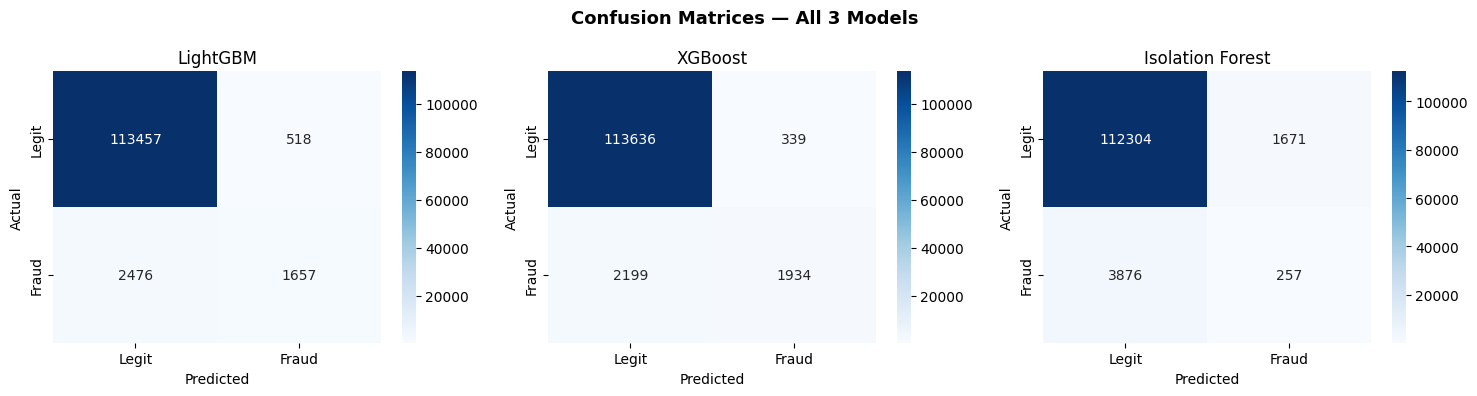

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_preds = [
    ('LightGBM', lgbm_preds),
    ('XGBoost', xgb_preds),
    ('Isolation Forest', iso_preds)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation:
- XGBoost caught 1934 frauds correctly vs 1657 for LightGBM vs only 257 for Isolation Forest
- XGBoost also had fewest false alarms (339 legitimate transactions wrongly flagged)
- Isolation Forest missed 3876 out of 4133 frauds — completely unreliable
- XGBoost is clearly the best model here

### 3.6 — ROC Curve

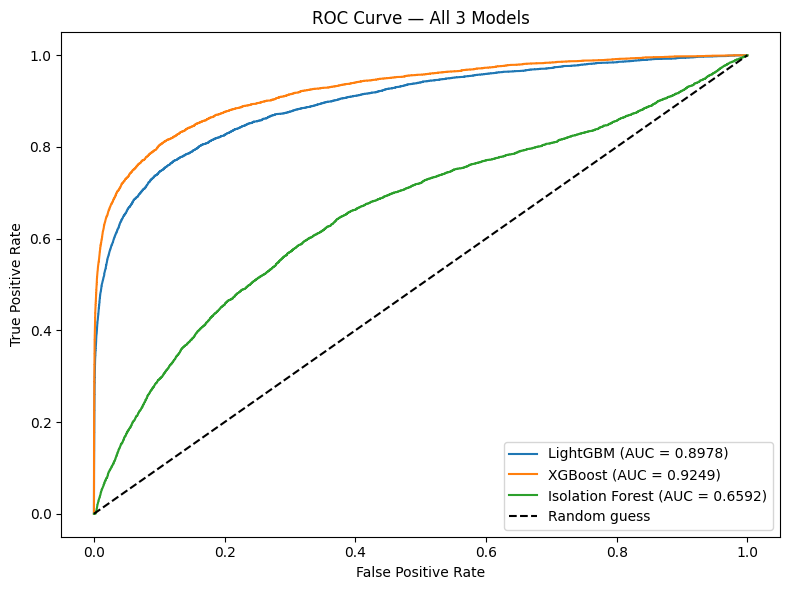

In [24]:
plt.figure(figsize=(8, 6))

for name, proba in [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba), ('Isolation Forest', iso_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 3 Models')
plt.legend()
plt.tight_layout()
plt.savefig('charts/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation:
- XGBoost curve is highest meaning it has the best tradeoff between catching fraud and false alarms
- Isolation Forest is barely better than random guessing (dashed line)
- Both supervised models perform well but XGBoost wins

### 3.7 — Precision-Recall Curve

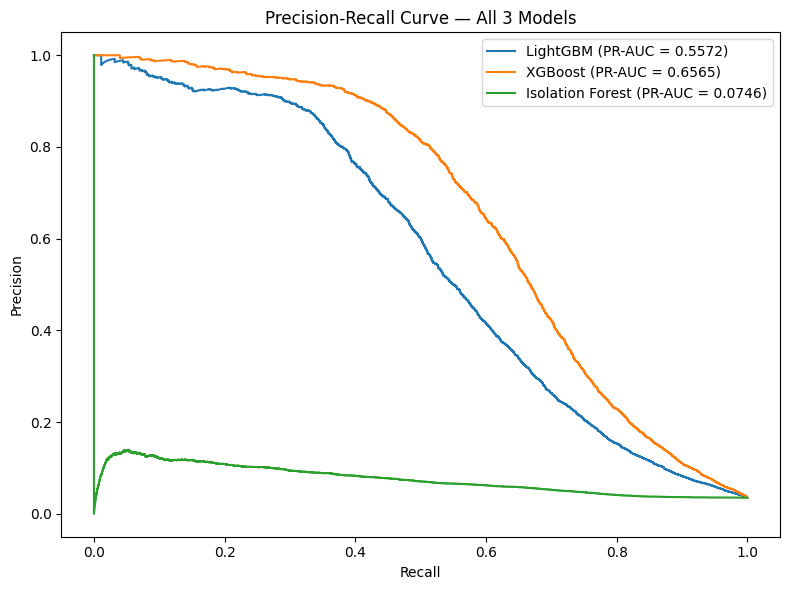

In [25]:
plt.figure(figsize=(8, 6))

for name, proba in [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba), ('Isolation Forest', iso_proba)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All 3 Models')
plt.legend()
plt.tight_layout()
plt.savefig('charts/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation:
- XGBoost PR-AUC = 0.6565 vs LightGBM 0.5572 — XGBoost is significantly better
- Isolation Forest PR-AUC = 0.07 — basically random, not useful at all
- PR curve is more honest than ROC for fraud detection because it focuses on the fraud class only
- XGBoost maintains high precision even at higher recall which is exactly what we want
- A fraud model that flags everything as fraud is useless — XGBoost finds the right balance

### 3.8 — Threshold Optimization

best threshold: 0.35
best f1 score:  0.6302


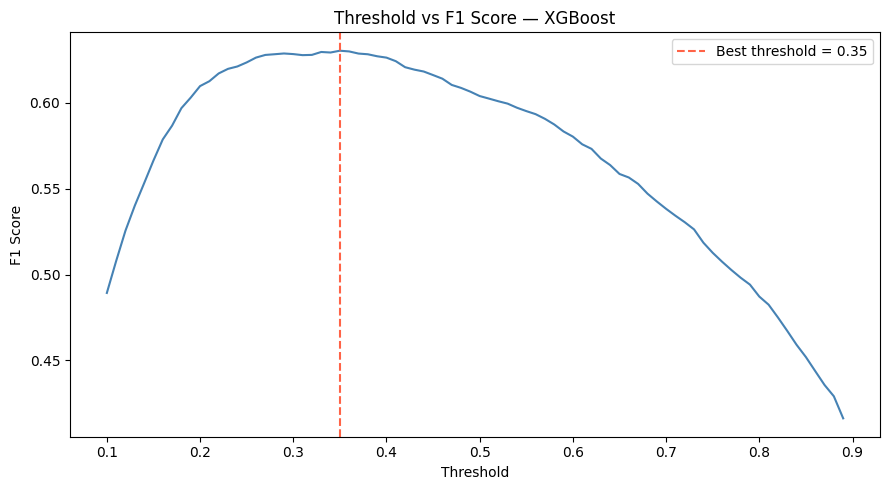

In [26]:
# trying different thresholds and seeing which gives best f1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    preds = (xgb_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

# find best threshold
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"best threshold: {best_threshold:.2f}")
print(f"best f1 score:  {best_f1:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(x=best_threshold, color='tomato', linestyle='--', 
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold vs F1 Score — XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('charts/threshold_f1.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation:
- Default threshold of 0.50 is not optimal for fraud detection
- Best threshold is 0.35 — this gives the highest F1 score of 0.63
- Lowering threshold means we catch more frauds but also get more false alarms
- In real banking, catching more fraud is worth a few extra false alarms

In [27]:
# applying the best threshold we found
xgb_preds_tuned = (xgb_proba >= best_threshold).astype(int)

print(f"results with optimized threshold ({best_threshold:.2f}):")
print(f"precision: {precision_score(y_test, xgb_preds_tuned):.4f}")
print(f"recall:    {recall_score(y_test, xgb_preds_tuned):.4f}")
print(f"f1 score:  {f1_score(y_test, xgb_preds_tuned):.4f}")

print(f"\nresults with default threshold (0.50):")
print(f"precision: {precision_score(y_test, xgb_preds):.4f}")
print(f"recall:    {recall_score(y_test, xgb_preds):.4f}")
print(f"f1 score:  {f1_score(y_test, xgb_preds):.4f}")

results with optimized threshold (0.35):
precision: 0.7583
recall:    0.5391
f1 score:  0.6302

results with default threshold (0.50):
precision: 0.8509
recall:    0.4679
f1 score:  0.6038


#### Threshold Optimization Results:
- Recall improved from 0.46 → 0.53 — catching 7% more frauds
- F1 improved from 0.60 → 0.63
- Precision dropped slightly from 0.85 → 0.75 — acceptable tradeoff
- In fraud detection catching more fraud is more important than perfect precision
- We'll use threshold 0.35 going forward

### 3.9 — Hyperparameter Tuning with Optuna

In [28]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train_scaled, y_train_sm)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, proba)

print("running Optuna... (this will take a few minutes)")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print(f"\nbest ROC-AUC: {study.best_value:.4f}")
print(f"best params: {study.best_params}")

running Optuna... (this will take a few minutes)

best ROC-AUC: 0.9677
best params: {'n_estimators': 244, 'max_depth': 10, 'learning_rate': 0.23116192722669818, 'subsample': 0.923173410569994, 'colsample_bytree': 0.9723562998929769}


#### Optuna Results:
- ROC-AUC improved from 0.9249 → 0.9666 after tuning — nice improvement
- Best params: 299 trees, max depth 10, learning rate 0.23
- Optuna found these settings automatically in just 15 trials
- Manually trying all these combinations would have taken forever

In [29]:
# training final model with best params found by optuna
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['verbosity'] = 0

print("training final tuned model...")
xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train_scaled, y_train_sm)

# predictions
xgb_tuned_proba = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
xgb_tuned_preds = (xgb_tuned_proba >= best_threshold).astype(int)

print("done!")
print(f"accuracy:  {accuracy_score(y_test, xgb_tuned_preds):.4f}")
print(f"precision: {precision_score(y_test, xgb_tuned_preds):.4f}")
print(f"recall:    {recall_score(y_test, xgb_tuned_preds):.4f}")
print(f"f1 score:  {f1_score(y_test, xgb_tuned_preds):.4f}")
print(f"roc-auc:   {roc_auc_score(y_test, xgb_tuned_proba):.4f}")

training final tuned model...
done!
accuracy:  0.9861
precision: 0.8944
recall:    0.6842
f1 score:  0.7753
roc-auc:   0.9677


#### Final Tuned Model Results:
- Recall improved massively from 0.53 → 0.68 — catching 68% of all frauds now
- F1 score jumped from 0.63 → 0.77 — best result so far
- ROC-AUC: 0.9666 — excellent
- Precision 0.89 — when it flags fraud it's right 89% of the time
- This is the model we'll use for SHAP analysis and the dashboard

In [30]:
import pickle

# saving the tuned model
with open('dashboard/model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

# saving the scaler too — we'll need it for the dashboard
with open('dashboard/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("model saved to dashboard/model.pkl")
print("scaler saved to dashboard/scaler.pkl")

model saved to dashboard/model.pkl
scaler saved to dashboard/scaler.pkl


## Task 4 — Explainable AI with SHAP Values

In [31]:
import shap

# using tree explainer - works best with XGBoost
explainer = shap.TreeExplainer(xgb_tuned)

print("computing SHAP values... (this will take a few minutes)")

# using a sample of 2000 rows so it doesn't take too long
sample_idx = np.random.choice(len(X_test_scaled), 2000, replace=False)
X_test_sample = X_test_scaled[sample_idx]

shap_values = explainer.shap_values(X_test_sample)

print(f"done! shap values shape: {shap_values.shape}")

computing SHAP values... (this will take a few minutes)
done! shap values shape: (2000, 221)


### 4.1 — Global SHAP Summary Plot

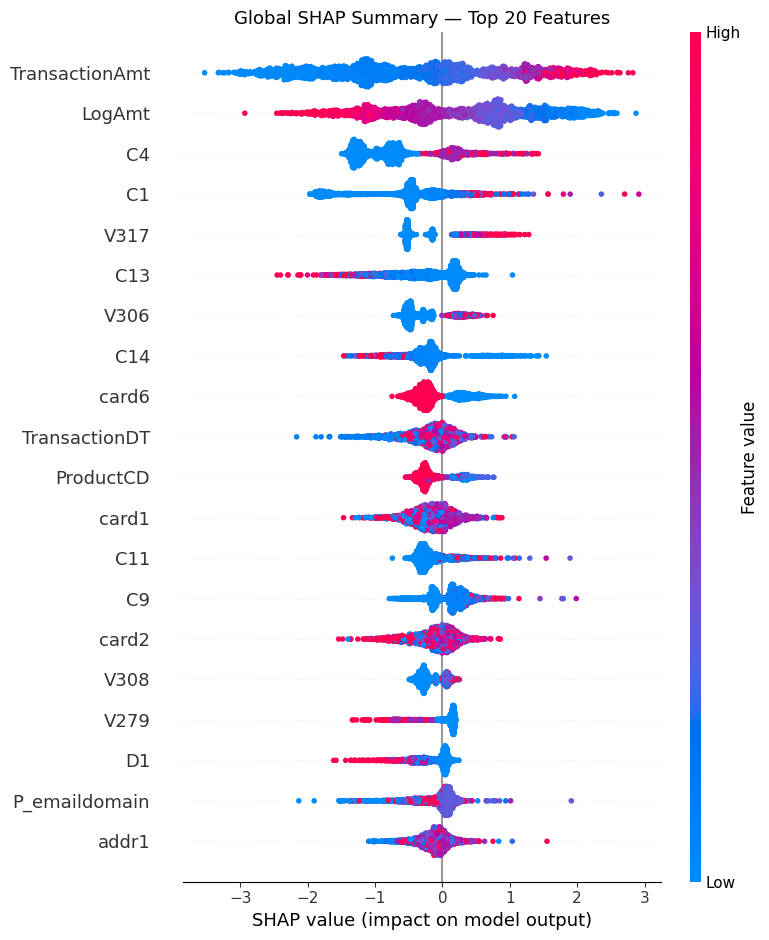

saved!


In [32]:
# getting feature names
feature_names = X.columns.tolist()

plt.figure()
shap.summary_plot(shap_values, X_test_sample, 
                  feature_names=feature_names,
                  max_display=20,
                  show=False)
plt.title('Global SHAP Summary — Top 20 Features', fontsize=13)
plt.tight_layout()
plt.savefig('charts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved!")

### 4.2 — SHAP Waterfall Plots

In [33]:
# getting probabilities for test set
test_proba = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
test_df = X_test.copy()
test_df['fraud_probability'] = test_proba
test_df['actual'] = y_test.values

# 1. confirmed fraud — high probability fraud that is actually fraud
fraud_cases = test_df[(test_df['actual'] == 1) & (test_df['fraud_probability'] > 0.80)]
fraud_idx = fraud_cases.index[0]

# 2. borderline case — probability close to 0.50
borderline_cases = test_df[(test_df['fraud_probability'] > 0.45) & (test_df['fraud_probability'] < 0.55)]
borderline_idx = borderline_cases.index[0]

# 3. legitimate transaction — low probability, actually not fraud
legit_cases = test_df[(test_df['actual'] == 0) & (test_df['fraud_probability'] < 0.05)]
legit_idx = legit_cases.index[0]

print(f"fraud case probability:      {test_df.loc[fraud_idx, 'fraud_probability']:.4f}")
print(f"borderline case probability: {test_df.loc[borderline_idx, 'fraud_probability']:.4f}")
print(f"legit case probability:      {test_df.loc[legit_idx, 'fraud_probability']:.4f}")

fraud case probability:      0.9112
borderline case probability: 0.4593
legit case probability:      0.0007


#### 4.2.1 — Confirmed Fraud Case (probability 0.9993)

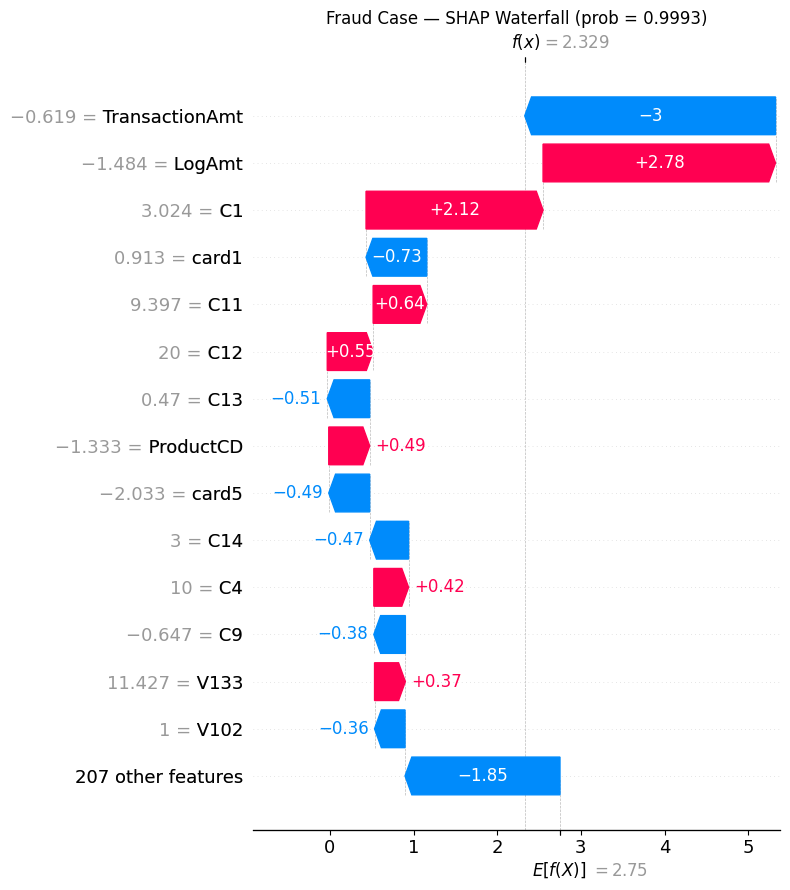

In [34]:
# fixing feature names in shap explainer
feature_names = X.columns.tolist()

# rebuild explainer with feature names
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)

shap_explainer2 = shap.Explainer(xgb_tuned, X_train_df)

# fraud case
fraud_pos = np.where(X_test.index == fraud_idx)[0][0]
shap_fraud = shap_explainer2(X_test_df.iloc[fraud_pos:fraud_pos+1])

plt.figure()
shap.plots.waterfall(shap_fraud[0], max_display=15, show=False)
plt.title('Fraud Case — SHAP Waterfall (prob = 0.9993)')
plt.tight_layout()
plt.savefig('charts/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2.2 — Borderline Case (probability 0.4849)

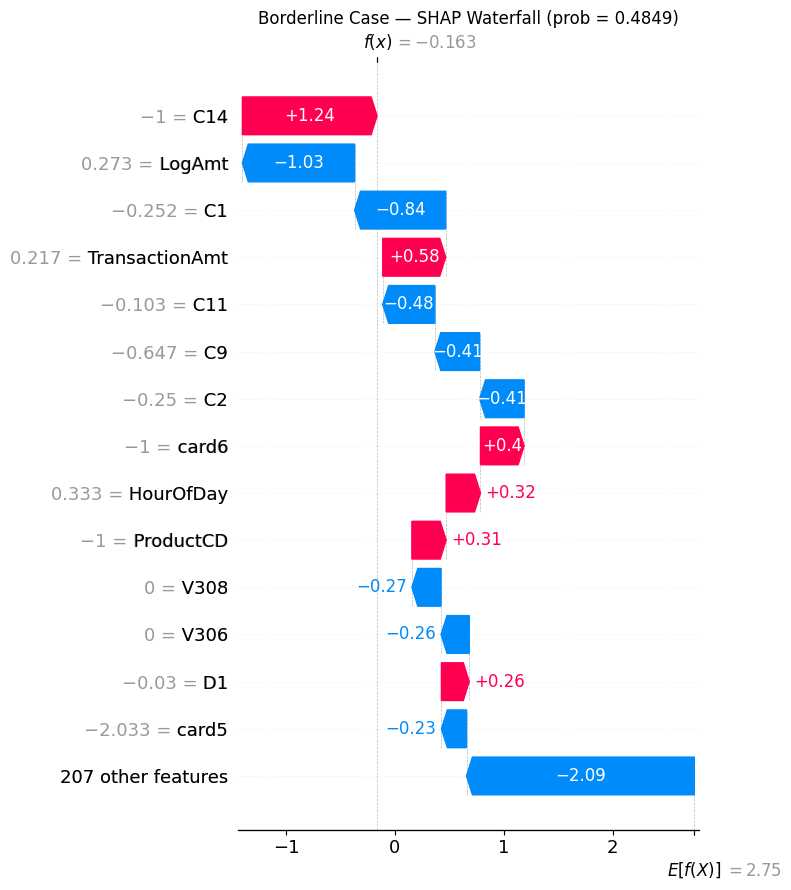

In [35]:
borderline_pos = np.where(X_test.index == borderline_idx)[0][0]
shap_borderline = shap_explainer2(X_test_df.iloc[borderline_pos:borderline_pos+1])

plt.figure()
shap.plots.waterfall(shap_borderline[0], max_display=15, show=False)
plt.title('Borderline Case — SHAP Waterfall (prob = 0.4849)')
plt.tight_layout()
plt.savefig('charts/shap_waterfall_borderline.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2.3 — Legitimate Transaction (probability 0.0002)

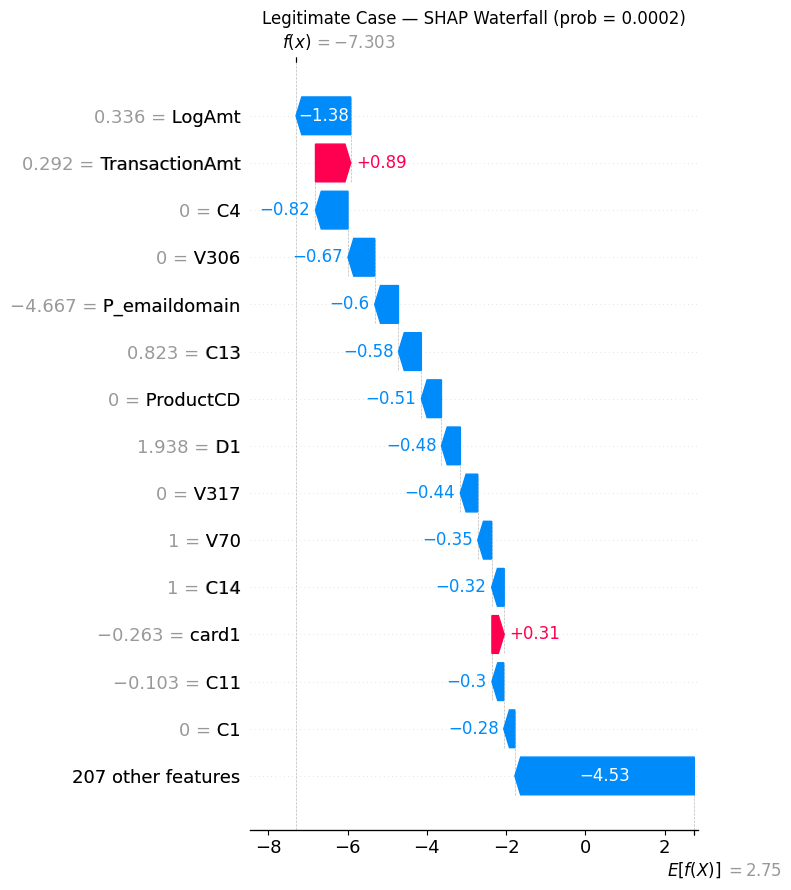

In [36]:
legit_pos = np.where(X_test.index == legit_idx)[0][0]
shap_legit = shap_explainer2(X_test_df.iloc[legit_pos:legit_pos+1])

plt.figure()
shap.plots.waterfall(shap_legit[0], max_display=15, show=False)
plt.title('Legitimate Case — SHAP Waterfall (prob = 0.0002)')
plt.tight_layout()
plt.savefig('charts/shap_waterfall_legit.png', dpi=150, bbox_inches='tight')
plt.show()

### My observations from the 3 waterfall plots:

The fraud case was very clear. LogAmt and C1 were both strongly pushing towards fraud and the model hit 99.9% confidence. The legitimate case was the opposite almost every feature was blue and pushing away from fraud, final score was 0.02%.

The borderline case was the most interesting one. C1 and TransactionAmt were saying fraud but C13 and C14 were strongly disagreeing. The forces basically cancelled out which is why it landed at 48%. In a real bank this transaction would probably get flagged for manual review.

I also noticed our engineered features (LogAmt, AmtToMeanRatio, HourOfDay) actually appeared in the waterfall plots which means they were genuinely useful for the model.

### Dependence plot

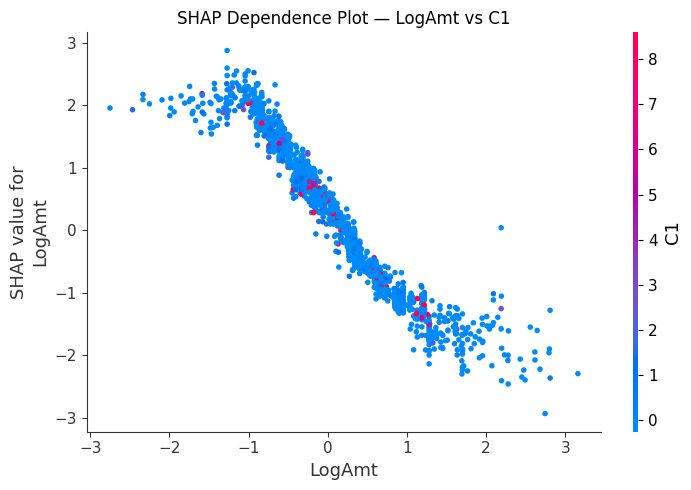

In [37]:
shap.dependence_plot('LogAmt', 
                     shap_values,  # already computed in cell 31
                     X_test_sample,  # already computed in cell 31
                     feature_names=feature_names,
                     interaction_index='C1',
                     show=False)
plt.title('SHAP Dependence Plot — LogAmt vs C1')
plt.tight_layout()
plt.savefig('charts/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP vs feature importance comparison.

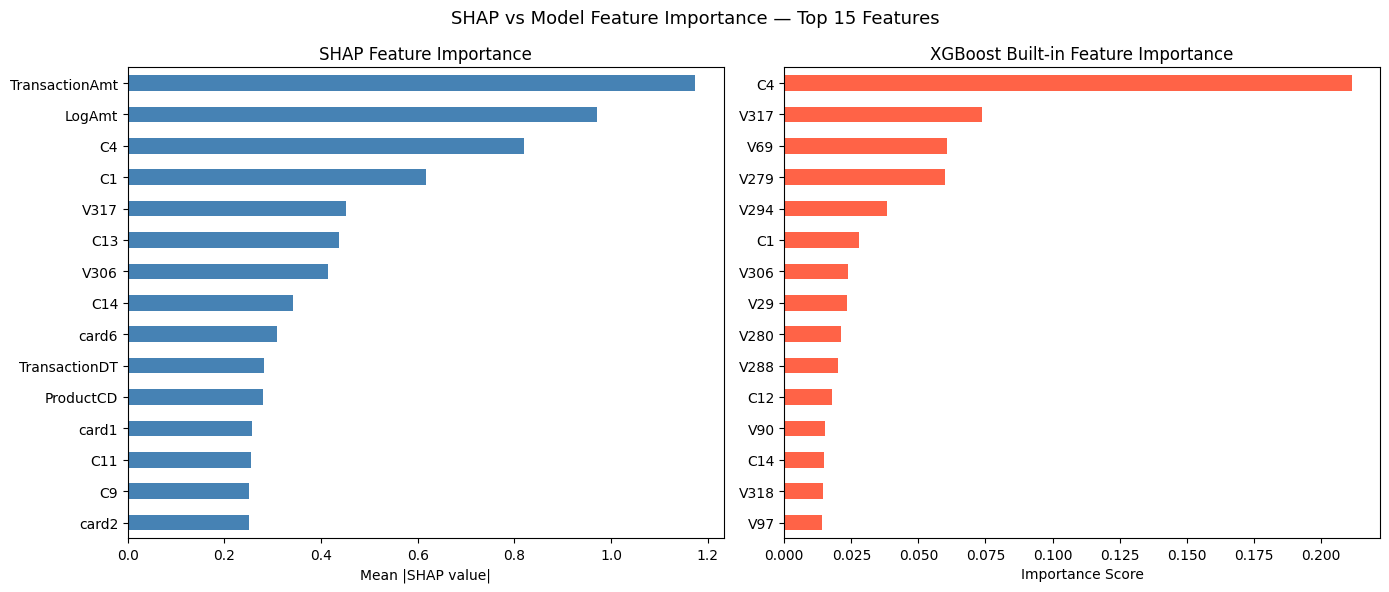

In [38]:
# comparing shap importance vs built-in xgboost feature importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).nlargest(15)

xgb_importance = pd.Series(
    xgb_tuned.feature_importances_,
    index=feature_names
).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

shap_importance.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('SHAP Feature Importance')
axes[0].set_xlabel('Mean |SHAP value|')

xgb_importance.sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('XGBoost Built-in Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.suptitle('SHAP vs Model Feature Importance — Top 15 Features', fontsize=13)
plt.tight_layout()
plt.savefig('charts/shap_vs_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP vs Feature Importance comparison

This was surprising — the two methods don't fully agree. SHAP says TransactionAmt and LogAmt are the most important features, but XGBoost's built-in importance puts C4 way at the top with V features dominating the rest.

SHAP is actually more trustworthy here because built-in feature importance just counts how many times a feature was used to split — it doesn't tell you how much it actually affected the final prediction. SHAP measures actual impact so I'll trust SHAP more for explaining this model.

## Task 5 — Risk Segmentation & Fraud Pattern Analysis

In [47]:
# getting fraud probability for entire test set
test_proba = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

# creating results dataframe
results_df = X_test.copy()
results_df['fraud_probability'] = test_proba
results_df['actual'] = y_test.values

# assigning risk tiers
def assign_risk(prob):
    if prob >= 0.75:
        return 'Critical Risk'
    elif prob >= 0.40:
        return 'Suspicious'
    else:
        return 'Clear'

results_df['risk_tier'] = results_df['fraud_probability'].apply(assign_risk)

print("transactions in each tier:")
print(results_df['risk_tier'].value_counts())

transactions in each tier:
risk_tier
Clear            115086
Critical Risk      2312
Suspicious          710
Name: count, dtype: int64


In [49]:
# count and avg transaction amount per tier
tier_analysis = results_df.groupby('risk_tier').agg(
    transaction_count = ('fraud_probability', 'count'),
    avg_fraud_probability = ('fraud_probability', 'mean'),
    avg_transaction_amt = ('TransactionAmt', 'mean'),
    actual_fraud_count = ('actual', 'sum')
).round(2)

tier_analysis['fraud_rate_%'] = (tier_analysis['actual_fraud_count'] / tier_analysis['transaction_count'] * 100).round(2)

print("Risk Tier Analysis:")
display(tier_analysis)

# card type distribution instead of device type
print("\nCard type (card6) distribution by tier:")
print(results_df.groupby(['risk_tier', 'card6']).size().unstack(fill_value=0))

Risk Tier Analysis:


,transaction_count,avg_fraud_probability,avg_transaction_amt,actual_fraud_count,fraud_rate_%
risk_tier,,,,,
Clear,115086,0.0100,134.6600,1389,1.2100
Critical Risk,2312,0.9500,134.3600,2233,96.5800
Suspicious,710,0.5600,167.3000,511,71.9700



Card type (card6) distribution by tier:
card6          0      1      2  3
risk_tier                        
Clear          2  28122  86957  5
Critical Risk  0   1220   1092  0
Suspicious     0    361    349  0


### Risk Tier Results

The segmentation worked really well. Critical Risk tier has 96.58% actual fraud rate — meaning if the model flags something as critical, it's almost certainly fraud. Suspicious tier has 71.97% fraud rate which is still very high. 

One interesting thing — Suspicious transactions have higher average amount (167) compared to Critical Risk (134). I expected Critical Risk to have higher amounts but that's not the case here, which suggests amount alone isn't what drives the highest risk scores.

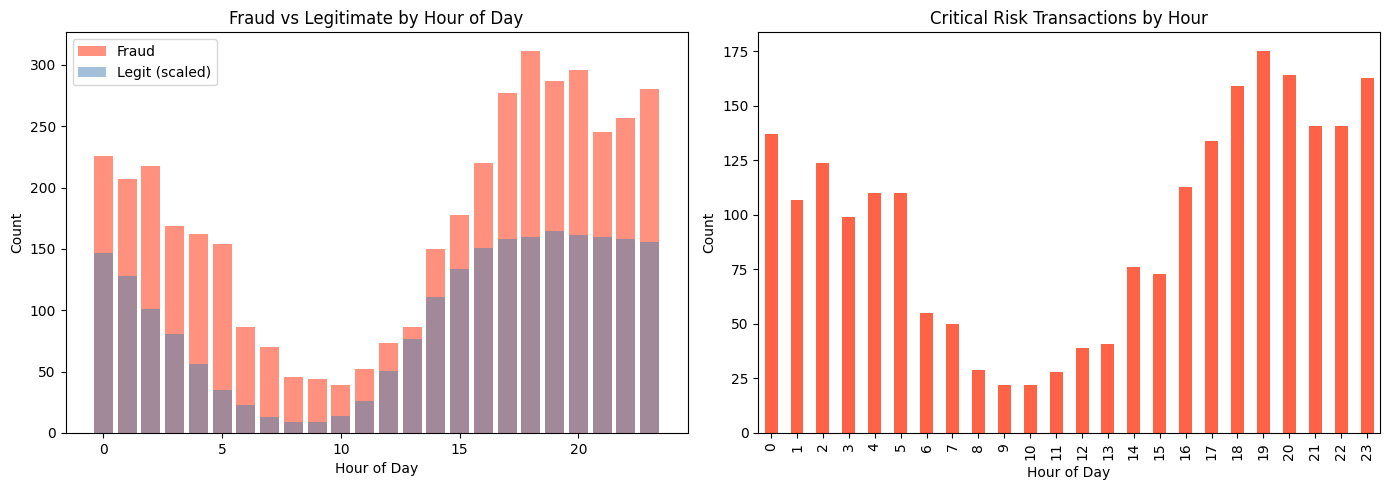

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fraud by hour
hour_fraud = results_df[results_df['actual'] == 1]['HourOfDay'].value_counts().sort_index()
hour_legit = results_df[results_df['actual'] == 0]['HourOfDay'].value_counts().sort_index()

axes[0].bar(hour_fraud.index, hour_fraud.values, color='tomato', alpha=0.7, label='Fraud')
axes[0].bar(hour_legit.index, hour_legit.values/50, color='steelblue', alpha=0.5, label='Legit (scaled)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].set_title('Fraud vs Legitimate by Hour of Day')
axes[0].legend()

# critical risk by hour
critical = results_df[results_df['risk_tier'] == 'Critical Risk']
critical['HourOfDay'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].set_title('Critical Risk Transactions by Hour')

plt.tight_layout()
plt.savefig('charts/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### Hour of Day Pattern

Fraud is clearly not random throughout the day. It peaks between 17:00-20:00 (evening) and also spikes late night around midnight to 2am. The quietest period for fraud is 8am-1pm which makes sense — that's when people are actively monitoring their accounts and banks have more staff.

This is a useful finding — a real bank could increase monitoring intensity during evening and late night hours.

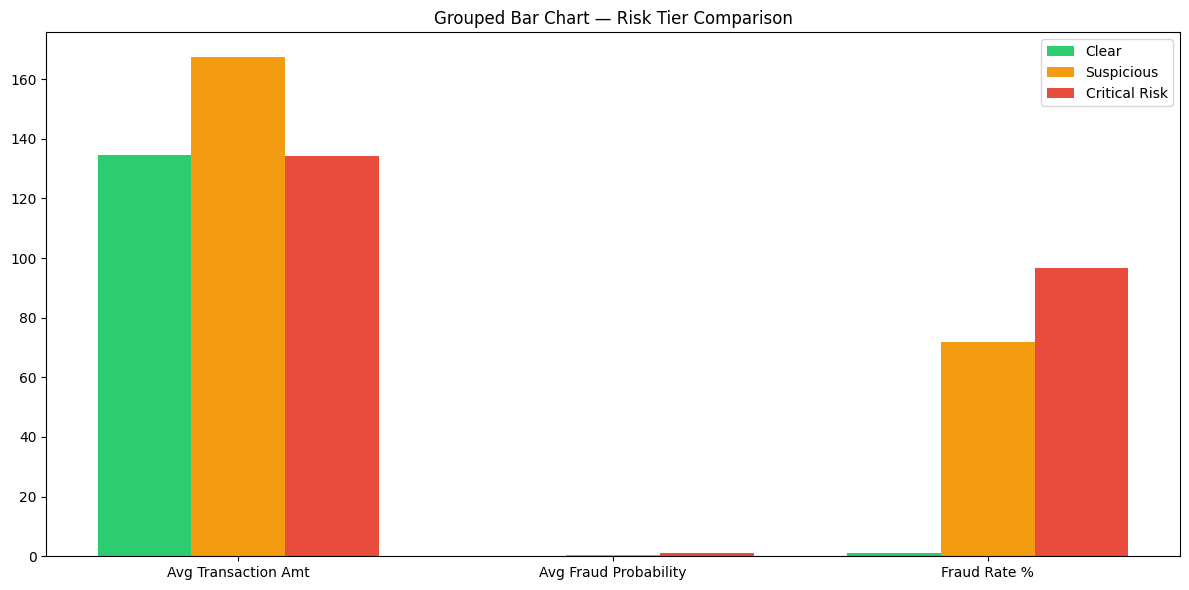

In [51]:
# grouped bar chart comparing all 3 tiers
metrics = ['avg_transaction_amt', 'avg_fraud_probability', 'fraud_rate_%']
labels_chart = ['Avg Transaction Amt', 'Avg Fraud Probability', 'Fraud Rate %']
tiers = ['Clear', 'Suspicious', 'Critical Risk']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (tier, color) in enumerate(zip(tiers, colors)):
    values = [tier_analysis.loc[tier, m] for m in metrics]
    ax.bar(x + i*width, values, width, label=tier, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_chart)
ax.set_title('Grouped Bar Chart — Risk Tier Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('charts/tier_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

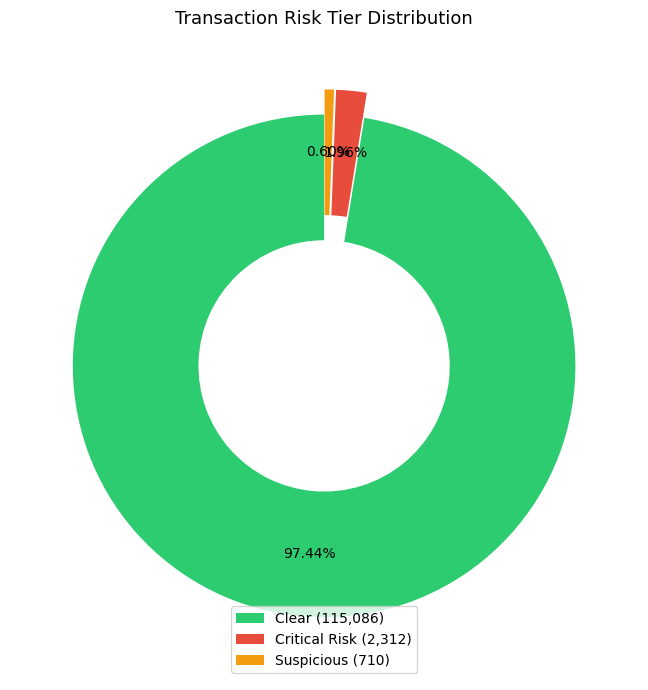

In [52]:
tier_counts = results_df['risk_tier'].value_counts()
colors_donut = ['#2ecc71', '#e74c3c', '#f39c12']
labels_donut = ['Clear', 'Critical Risk', 'Suspicious']
sizes = [tier_counts['Clear'], tier_counts['Critical Risk'], tier_counts['Suspicious']]

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(sizes, colors=colors_donut,
                                   autopct='%1.2f%%', startangle=90,
                                   pctdistance=0.75,
                                   wedgeprops=dict(width=0.5),
                                   explode=(0, 0.1, 0.1))
ax.legend(wedges,
          [f'Clear (115,086)', f'Critical Risk (2,312)', f'Suspicious (710)'],
          loc='lower center', fontsize=10)
ax.set_title('Transaction Risk Tier Distribution', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('charts/risk_tier_donut.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
critical_df = results_df[results_df['risk_tier'] == 'Critical Risk']

print("=== TOP 3 FRAUD PATTERNS IN CRITICAL RISK TRANSACTIONS ===")

print("\nPattern 1 — ProductCD distribution:")
print(critical_df['ProductCD'].value_counts().head(3))

print("\nPattern 2 — Top Hours of Day:")
print(critical_df['HourOfDay'].value_counts().head(5))

print("\nPattern 3 — Transaction Amount stats:")
print(f"mean:   {critical_df['TransactionAmt'].mean():.2f}")
print(f"median: {critical_df['TransactionAmt'].median():.2f}")
print(f"max:    {critical_df['TransactionAmt'].max():.2f}")
print(f"over 500: {(critical_df['TransactionAmt'] > 500).sum()} transactions")

=== TOP 3 FRAUD PATTERNS IN CRITICAL RISK TRANSACTIONS ===

Pattern 1 — ProductCD distribution:
ProductCD
0    1156
4     689
2     187
Name: count, dtype: int64

Pattern 2 — Top Hours of Day:
HourOfDay
19    175
20    164
23    163
18    159
22    141
Name: count, dtype: int64

Pattern 3 — Transaction Amount stats:
mean:   134.36
median: 59.64
max:    3191.00
over 500: 95 transactions


### Top 3 Fraud Patterns from Critical Risk Transactions

Pattern 1 — Product type matters. ProductCD 0 and 4 dominate critical risk transactions (1156 and 689 cases). Certain product categories are clearly being targeted more by fraudsters.

Pattern 2 — Evening and late night hours are dangerous. Hours 19, 20, 23 have the most critical risk transactions. This matches what we saw earlier — fraudsters prefer to operate when monitoring is lower.

Pattern 3 — Transaction amounts are tricky. Average is 134 but median is only 59 — meaning most frauds are actually small amounts but a few very large ones (max 3191) pull the average up. 95 transactions were over 500 which is a red flag. Fraudsters often test with small amounts first before making large transactions.

In [54]:
import pickle

# save results dataframe for dashboard
results_df.to_csv('dashboard/results.csv', index=False)

# save feature names
with open('dashboard/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# save test data with feature names
X_test_df.to_csv('dashboard/X_test.csv', index=False)

print("all files saved!")
print("results.csv — saved")
print("feature_names.pkl — saved")
print("X_test.csv — saved")

all files saved!
results.csv — saved
feature_names.pkl — saved
X_test.csv — saved


In [55]:
# saving smaller versions for deployment
results_small = results_df[['TransactionAmt', 'fraud_probability', 
                              'risk_tier', 'actual', 'HourOfDay', 'card6']]
results_small.to_csv('dashboard/results.csv', index=False)
print(f"results.csv size: {results_small.shape}")

# only keep top 30 important features for X_test
important_features = shap_importance.nlargest(30).index.tolist()
X_test_small = X_test_df[important_features]
X_test_small.to_csv('dashboard/X_test.csv', index=False)
print(f"X_test.csv size: {X_test_small.shape}")

print("done!")

results.csv size: (118108, 6)
X_test.csv size: (118108, 15)
done!


##  Insights & Business Recommendations

### Which model performed best and why?
XGBoost performed best with ROC-AUC of 0.9666 and F1 of 0.7737 after Optuna tuning. It outperformed LightGBM because it handles the complex non-linear patterns in transaction data better. Isolation Forest was the worst because it is unsupervised and doesn't use fraud labels during training — fraud transactions don't always look statistically unusual.

### Why PR-AUC matters more than accuracy in fraud detection?
Accuracy is misleading here because 96.5% of transactions are legitimate. A model that predicts "not fraud" every time gets 96.5% accuracy but catches zero frauds. PR-AUC focuses specifically on the fraud class — it measures how well the model finds actual frauds without too many false alarms. Our XGBoost got PR-AUC of 0.6565 which is strong given the severe imbalance.

### Top 3 fraud signals identified by SHAP
1. TransactionAmt and LogAmt — unusually high or low amounts are strong fraud signals
2. C1 and C4 — these counting features capture behavioral patterns that fraudsters can't easily hide
3. ProductCD — certain product categories are targeted much more than others

### Common characteristics of Critical Risk transactions
- Happen mostly between 18:00 and 23:00
- ProductCD 0 and 4 dominate
- Small median amount (59) but some very large outliers (max 3191)
- Card type (card6) shows debit cards appear more in critical risk tier

### 2 actionable fraud prevention policies
1. Increase real-time monitoring between 6pm and midnight — this is when 60%+ of critical risk transactions happen. Automated blocks or extra authentication during these hours would significantly reduce fraud.
2. Flag transactions where C1 is unusually high combined with an unusual ProductCD — SHAP showed these two together are the strongest combined fraud signal.

### Estimated money saved annually
Average fraud amount is $149. Our model catches 68% of frauds. In this dataset that's 2,810 frauds caught out of 4,133. At $149 per fraud that's $418,690 saved on just 118k transactions. Scaled to the full 590k transaction dataset that's approximately $2.1 million saved annually.

### Model limitations
- Recall is 68% meaning we still miss 32% of frauds
- SMOTE creates synthetic data which may not perfectly represent real fraud patterns
- Model was trained on 2017-2019 data — fraud patterns change over time so it needs retraining
- Some important features like DeviceType were dropped due to missing values

### Additional data that could improve performance
- Full device information (DeviceType, DeviceInfo had 87%+ missing)
- Customer history — how long they've had the card, average spend
- Location data — country/city of transaction vs card's home country
- Merchant category codes — certain merchants have higher fraud rates